# Genre steering sweep (multiplicative on `c_hat`)

Uses `evaluate_with_recbole` from `steering_utils`, so every row is a full RecBole
evaluation with the same metric set you use elsewhere.

One genre steered at a time, across a range of factors. `GenreExposure` gives the
exposure of **every** genre in each run, so the target effect and the spillover onto
untargeted genres come out of the same evaluation.

Output: long-format CSV, one row per (steered genre, factor, measured genre).

## 1. Settings

In [40]:
DATASET   = "ml-1m"
DATA_PATH = f"dataset/{DATASET}"
CBM_MODEL = "saved/SASRec_CBM-ml-1mm_sigmoid_New.pth"

N_AMPLIFY_POOL = 5     # amplify target drawn from the N lowest-c_hat genres


SUPPRESS_F = 0.8
AMPLIFY_F  = 1.5

K    = 20
SEED = 42

OUT = f"./dataset/{DATASET}/results/local_genre_steering_k{K}.csv"

## 2. Load model + config overrides

In [41]:
import os
import numpy as np
import pandas as pd
import torch
from recbole.quick_start import load_data_and_model

config, cbm, dataset, train_data, valid_data, test_data = load_data_and_model(
    config_dict={"data_path": DATA_PATH, "dataset": DATASET},
    model_file=CBM_MODEL,
)
cbm.eval()
device = next(cbm.parameters()).device

names       = list(cbm.concept_names)
genre_idx   = list(range(21, 24))
genre_names = [names[j] for j in genre_idx]

item_concepts = cbm.item_concepts.to(device)          # [n_items, n_concepts]
is_seq = hasattr(cbm, "ITEM_SEQ")                      # SASRec vs LightGCN

N_AMP = min(N_AMPLIFY_POOL, len(genre_idx) - 1)
assert N_AMP >= 1, "need at least 2 genres"
if N_AMP != N_AMPLIFY_POOL:
    print(f"NOTE: only {len(genre_idx)} genres, amplify pool trimmed to {N_AMP}")

print(type(cbm).__name__, "|", config["dataset"], "|", device)
print(f"{len(genre_names)} genres: {genre_names}")

/home/mvarasteh/post-hoc/recbole/quick_start/quick_start.py:249: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_file, map_location=torch.device(

[build] Dataset: ml-1m
[build] Building concept lookups...
  pop_set:   343 items (≥ 760 interactions)
  mid_set:   2,716 items
  niche_set: 357 items (1–18 interactions)
  Items in metadata: 3,416, matched to internal IDs: 3,416
  N_CONCEPTS = 24  (18 genres + 6 scalars)
[build] Computing per-item concept vectors for 3,417 items...

[build] Saved concept matrix (3417, 24) → ./dataset/ml-1m/saved_concept_individual_items.pkl

[build] Diagnostics — items with NO ...
  ... primary features : 1 (should be ~1, padding)
  ... tier features    : 1 (items w/ 0 interactions)
  ... secondary feats  : 1 (items missing metadata)
  mean genres/item     : 1.00

[build] Spot check — item 1:
  Drama                     1.0000
  popularity                1.0000
  retro                     1.0000
[CBM] 3417 items × 24 concepts  +  64 free dims
NOTE: only 3 genres, amplify pool trimmed to 2
SASRec_CBM | ml-1m | cuda:0
3 genres: ['classic', 'retro', 'modern']


## 3. Forward with scaled `c_hat`

`factors` is `[B, n_concepts]`, so each row gets its own suppress/amplify pair.
`c_hat` is clamped to [0,1] — it's a sigmoid output, and the reconstructor never
saw values outside that range during training.

In [42]:
@torch.no_grad()
def scores_and_chat(model, interaction, factors=None, k=10):
    """Returns (topk_items, c_hat_before, c_hat_after)."""
    if is_seq:
        seq     = interaction[model.ITEM_SEQ]
        seq_len = interaction[model.ITEM_SEQ_LEN]
        h       = model._encode(seq, seq_len)
        item_e  = model.item_embedding.weight
    else:
        user   = interaction[model.USER_ID]
        h      = model._ensure_propagated()[0][user]
        item_e = model._ensure_propagated()[1]
        seq    = None

    c_before = torch.sigmoid(model.concept_predictor(h))
    z        = model.latent_predictor(h)

    c_after = c_before if factors is None else (c_before * factors).clamp(0, 1)
    h_hat   = model.reconstructor(torch.cat([c_after, z], dim=-1))

    scores = h_hat @ item_e.T
    scores[:, 0] = -np.inf                       # PAD item
    if seq is not None:                          # don't recommend history
        scores.scatter_(1, seq, -np.inf)

    return torch.topk(scores, k, dim=1).indices, c_before, c_after


@torch.no_grad()
def genre_exposure(topk_idx):
    """Fraction of the top-k carrying each genre. -> [B, n_genres]"""
    memb = (item_concepts[:, genre_idx] > 0).float()
    return memb[topk_idx].mean(dim=1)

## 4. Run

`interventions={}` is the unsteered CBM — the correct reference point. Not the frozen
LightGCN, which would fold the CBM's reconstruction cost into every steering delta.

In [43]:
rng  = np.random.default_rng(SEED)   # unused now, harmless
rows = []

AMPLIFY_RANK = 1      # 0 = largest, 2 = 3rd largest
assert len(genre_idx) > AMPLIFY_RANK, "not enough genres"


def ndcg_at_k(topk_idx, pos_items):
    """Leave-one-out NDCG@K: one relevant item per row. -> [B] numpy"""
    hit   = (topk_idx == pos_items.unsqueeze(1))          # [B, K]
    ranks = hit.float().argmax(dim=1)                     # 0-indexed
    found = hit.any(dim=1)
    ndcg  = torch.where(found, 1.0 / torch.log2(ranks.float() + 2),
                        torch.zeros(len(ranks), device=topk_idx.device))
    return ndcg.cpu().numpy()


for batch in test_data:
    interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
    interaction = interaction.to(device)

    # baseline
    top_b, c_b, _ = scores_and_chat(cbm, interaction, None, K)
    exp_b = genre_exposure(top_b).cpu().numpy()
    B = len(top_b)

    # ── ground-truth item for NDCG ──────────────────────────────────────
    if isinstance(batch, (list, tuple)) and len(batch) >= 4 and batch[3] is not None:
        pos_u, pos_i = batch[2].to(device), batch[3].to(device)
        pos_items = torch.zeros(B, dtype=torch.long, device=device)
        pos_items[pos_u] = pos_i
    else:
        pos_items = interaction[cbm.ITEM_ID]

    cg = c_b[:, genre_idx]                                  # [B, n_genres]

    # rank of each genre by c_hat (0 = highest)
    order = cg.argsort(dim=1, descending=True)              # [B, n_genres]
    rank = torch.empty_like(order)
    rank.scatter_(1, order, torch.arange(cg.size(1), device=device).expand_as(order))
    rank = rank.cpu().numpy()

    # suppress: rank 0 (largest c_hat).  amplify: rank AMPLIFY_RANK (3rd largest)
    s_col = order[:, 0]
    a_col = order[:, AMPLIFY_RANK]

    s_pick = np.array([genre_idx[c] for c in s_col.cpu().numpy()])
    a_pick = np.array([genre_idx[c] for c in a_col.cpu().numpy()])

    factors = torch.ones(B, cbm.n_concepts, device=device)
    rr = torch.arange(B, device=device)
    factors[rr, torch.as_tensor(s_pick, device=device)] = SUPPRESS_F
    factors[rr, torch.as_tensor(a_pick, device=device)] = AMPLIFY_F

    # steered
    top_s, _, c_a = scores_and_chat(cbm, interaction, factors, K)
    exp_s = genre_exposure(top_s).cpu().numpy()

    # ── NDCG before / after ─────────────────────────────────────────────
    ndcg_b = ndcg_at_k(top_b, pos_items)
    ndcg_s = ndcg_at_k(top_s, pos_items)

    cb, ca = c_b.cpu().numpy(), c_a.cpu().numpy()
    uid = (interaction[cbm.USER_ID].cpu().numpy()
           if cbm.USER_ID in interaction.interaction else np.arange(B))

    for i in range(B):
        for col, j in enumerate(genre_idx):
            role = ("suppressed" if j == s_pick[i] else
                    "amplified"  if j == a_pick[i] else "untargeted")
            rows.append({
                "user_id": int(uid[i]),
                "genre": names[j],
                "role": role,
                "c_hat_rank": int(rank[i, col]),        # 0 = highest c_hat
                "target_suppress": names[s_pick[i]],
                "target_amplify":  names[a_pick[i]],
                "factor": float(factors[i, j]),
                "c_hat_before": float(cb[i, j]),
                "c_hat_after":  float(ca[i, j]),
                "delta_c_hat":  float(ca[i, j] - cb[i, j]),
                "exposure_before": float(exp_b[i, col]),
                "exposure_after":  float(exp_s[i, col]),
                "delta_exposure":  float(exp_s[i, col] - exp_b[i, col]),
                "count_before": int(round(exp_b[i, col] * K)),
                "count_after":  int(round(exp_s[i, col] * K)),
                "ndcg_before": float(ndcg_b[i]),
                "ndcg_after":  float(ndcg_s[i]),
                "delta_ndcg":  float(ndcg_s[i] - ndcg_b[i]),
            })

df = pd.DataFrame(rows)
os.makedirs(os.path.dirname(OUT), exist_ok=True)
df.to_csv(OUT, index=False)
print(f"{len(df)} rows, {df.user_id.nunique()} users -> {OUT}")
print(f"NDCG@{K}: {df.drop_duplicates('user_id').ndcg_before.mean():.4f} -> "
      f"{df.drop_duplicates('user_id').ndcg_after.mean():.4f}")

18120 rows, 6040 users -> ./dataset/ml-1m/results/local_genre_steering_k20.csv
NDCG@20: 0.2057 -> 0.1987


In [44]:
data = pd.read_csv("./dataset/ml-1m/results/local_genre_steering_k20.csv")

filtered = data[(data['user_id'] == 400)]
filtered

,user_id,genre,role,c_hat_rank,target_suppress,target_amplify,factor,c_hat_before,c_hat_after,delta_c_hat,exposure_before,exposure_after,delta_exposure,count_before,count_after,ndcg_before,ndcg_after,delta_ndcg
16902,400,classic,untargeted,2,modern,retro,1.0,0.012234,0.012234,0.000000,0.0,0.0,0.0,0,0,0.25,0.244651,-0.005349
16903,400,retro,amplified,1,modern,retro,1.5,0.140236,0.210354,0.070118,0.0,0.0,0.0,0,0,0.25,0.244651,-0.005349
16904,400,modern,suppressed,0,modern,retro,0.8,0.796141,0.636913,-0.159228,1.0,1.0,0.0,20,20,0.25,0.244651,-0.005349


In [47]:
df

,user_id,genre,role,c_hat_rank,target_suppress,target_amplify,factor,c_hat_before,c_hat_after,delta_c_hat,exposure_before,exposure_after,delta_exposure,count_before,count_after,ndcg_before,ndcg_after,delta_ndcg
0,6040,classic,untargeted,2,modern,retro,1.0,0.177970,0.177970,0.000000,0.00,0.00,0.00,0,0,0.000000,0.000000,0.000000
1,6040,retro,amplified,1,modern,retro,1.5,0.349080,0.523620,0.174540,0.15,0.90,0.75,3,18,0.000000,0.000000,0.000000
2,6040,modern,suppressed,0,modern,retro,0.8,0.455669,0.364535,-0.091134,0.85,0.10,-0.75,17,2,0.000000,0.000000,0.000000
3,6039,classic,suppressed,0,classic,modern,0.8,0.359936,0.287949,-0.071987,0.70,0.60,-0.10,14,12,0.430677,0.333333,-0.097343
4,6039,retro,untargeted,2,classic,modern,1.0,0.317824,0.317824,0.000000,0.15,0.25,0.10,3,5,0.430677,0.333333,-0.097343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18115,2910,retro,amplified,1,modern,retro,1.5,0.394472,0.591708,0.197236,0.65,1.00,0.35,13,20,0.000000,0.000000,0.000000
18116,2910,modern,suppressed,0,modern,retro,0.8,0.543747,0.434997,-0.108749,0.35,0.00,-0.35,7,0,0.000000,0.000000,0.000000
18117,2947,classic,untargeted,2,modern,retro,1.0,0.007915,0.007915,0.000000,0.00,0.00,0.00,0,0,0.000000,0.000000,0.000000
18118,2947,retro,amplified,1,modern,retro,1.5,0.183844,0.275765,0.091922,0.00,0.00,0.00,0,0,0.000000,0.000000,0.000000


## Ploting

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sup = df[df.role == "suppressed"].drop_duplicates("user_id").copy()

bins   = np.arange(0, 1.0001, 0.1)
sup["bin"] = pd.cut(sup.exposure_before, bins, in"clude_lowest=True)
grp = sup.groupby("bin", observed=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
data   = [g.exposure_after.values for _, g in grp]
centers = [iv.mid for iv in grp.groups.keys()]
counts  = [len(g) for _, g in grp]

ax.boxplot(data, positions=centers, widths=0.07, showfliers=False,
           medianprops=dict(color="tab:orange", lw=2))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="no change")
for c, n, d in zip(centers, counts, data):
    ax.text(c, 1.03, f"n={n}", ha="center", fontsize=7, rotation=90)

ax.set_xticks(np.round(centers, 2))
ax.set_xticklabels([f"{c:.2f}" for c in centers])
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.15)
ax.set_xlabel("exposure before (binned)"); ax.set_ylabel("exposure after")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

SyntaxError: unterminated string literal (detected at line 8) (4028880784.py, line 8)

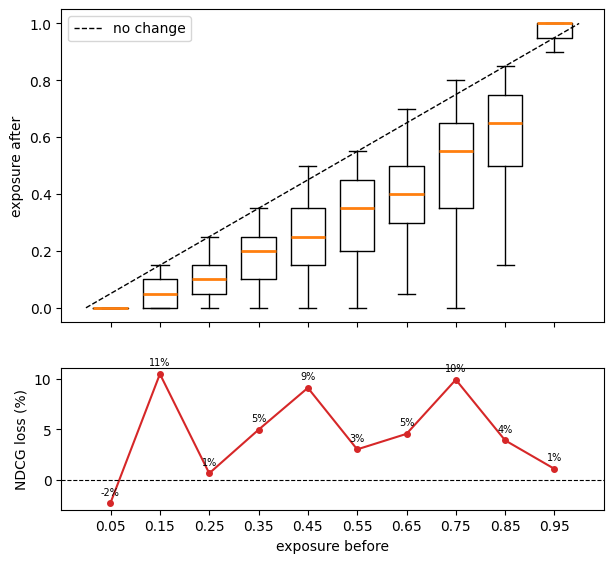

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sup = df[df.role == "suppressed"].drop_duplicates("user_id").copy()

bins = np.arange(0, 1.0001, 0.1)
sup["bin"] = pd.cut(sup.exposure_before, bins, include_lowest=True)
grp = sup.groupby("bin", observed=True)

data    = [g.exposure_after.values for _, g in grp]
centers = [iv.mid for iv in grp.groups.keys()]
counts  = [len(g) for _, g in grp]
nb      = grp.ndcg_before.mean().values
na      = grp.ndcg_after.mean().values

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(7, 6.5), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

ax.boxplot(data, positions=centers, widths=0.07, showfliers=False,
           medianprops=dict(color="tab:orange", lw=2))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="no change")
#for c, n in zip(centers, counts):
    #ax.text(c, 1.03, f"n={n}", ha="center", fontsize=7, rotation=90)
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("exposure after")
ax.legend(loc="upper left")

loss = (1 - grp.ndcg_after.mean() / grp.ndcg_before.mean()).values * 100

ax2.plot(centers, loss, "o-", color="tab:red", ms=4)
ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.set_xticks(np.round(centers, 2))
ax2.set_xticklabels([f"{c:.2f}" for c in centers])
ax2.set_xlim(-0.05, 1.05)
ax2.set_xlabel("exposure before")
ax2.set_ylabel(f"NDCG loss (%)")
for c, v in zip(centers, loss):
    ax2.annotate(f"{v:.0f}%", (c, v), textcoords="offset points",
                 xytext=(0, 6), ha="center", fontsize=7)

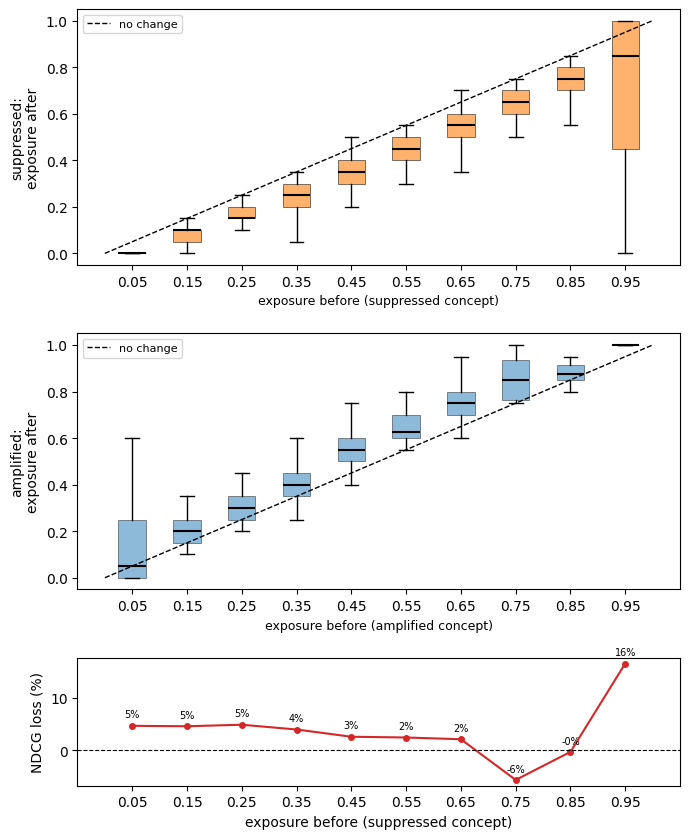

n per bin (suppressed): [111, 200, 300, 389, 662, 228, 693, 201, 494, 2762]
n per bin (amplified): [4381, 712, 447, 217, 168, 30, 57, 18, 8, 2]


In [108]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

users = df.drop_duplicates(["user_id", "role"]).copy()
bins  = np.arange(0, 1.0001, 0.1)

# each arm binned by its OWN baseline exposure, so both panels get a real
# 45-degree no-change diagonal
users["bin_sup"] = pd.cut(users.sup_exposure_before, bins, include_lowest=True)
users["bin_own"] = pd.cut(users.exposure_before,     bins, include_lowest=True)

sup = users[users.role == "suppressed"].groupby("bin_sup", observed=True)
amp = users[users.role == "amplified"].groupby("bin_own", observed=True)

centers_s = np.array([iv.mid for iv in sup.groups.keys()])
centers_a = np.array([iv.mid for iv in amp.groups.keys()])
sup_data  = [g.exposure_after.values for _, g in sup]
amp_data  = [g.exposure_after.values for _, g in amp]
counts_s  = [len(g) for _, g in sup]
counts_a  = [len(g) for _, g in amp]

fig, (ax, axa, ax2) = plt.subplots(3, 1, figsize=(7, 8.5),
                                   gridspec_kw={"height_ratios": [2, 2, 1]})

# ── suppressed ──────────────────────────────────────────────────────────
b1 = ax.boxplot(sup_data, positions=centers_s, widths=0.05, showfliers=False,
                patch_artist=True, medianprops=dict(color="black", lw=1.5))
for b in b1["boxes"]:
    b.set(facecolor="tab:orange", alpha=.6, lw=.6)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="no change")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.set_xticks(np.round(centers_s, 2))
ax.set_xticklabels([f"{c:.2f}" for c in centers_s])
ax.set_xlabel("exposure before (suppressed concept)", fontsize=9)
ax.set_ylabel("suppressed:\nexposure after")
ax.legend(loc="upper left", fontsize=8)

# ── amplified ───────────────────────────────────────────────────────────
b2 = axa.boxplot(amp_data, positions=centers_a, widths=0.05, showfliers=False,
                 patch_artist=True, medianprops=dict(color="black", lw=1.5))
for b in b2["boxes"]:
    b.set(facecolor="tab:blue", alpha=.5, lw=.6)
axa.plot([0, 1], [0, 1], "k--", lw=1, label="no change")
axa.set_xlim(-0.05, 1.05); axa.set_ylim(-0.05, 1.05)
axa.set_xticks(np.round(centers_a, 2))
axa.set_xticklabels([f"{c:.2f}" for c in centers_a])
axa.set_xlabel("exposure before (amplified concept)", fontsize=9)
axa.set_ylabel("amplified:\nexposure after")
axa.legend(loc="upper left", fontsize=8)

# ── cost, binned on the suppressed concept ──────────────────────────────
loss = (1 - sup.ndcg_after.mean() / sup.ndcg_before.mean()).values * 100
ax2.plot(centers_s, loss, "o-", color="tab:red", ms=4)
ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.set_xlim(-0.05, 1.05)
ax2.set_xticks(np.round(centers_s, 2))
ax2.set_xticklabels([f"{c:.2f}" for c in centers_s])
ax2.set_xlabel("exposure before (suppressed concept)")
ax2.set_ylabel("NDCG loss (%)")
for c, v in zip(centers_s, loss):
    ax2.annotate(f"{v:.0f}%", (c, v), textcoords="offset points",
                 xytext=(0, 6), ha="center", fontsize=7)

plt.tight_layout(); plt.show()
print("n per bin (suppressed):", counts_s)
print("n per bin (amplified):", counts_a)

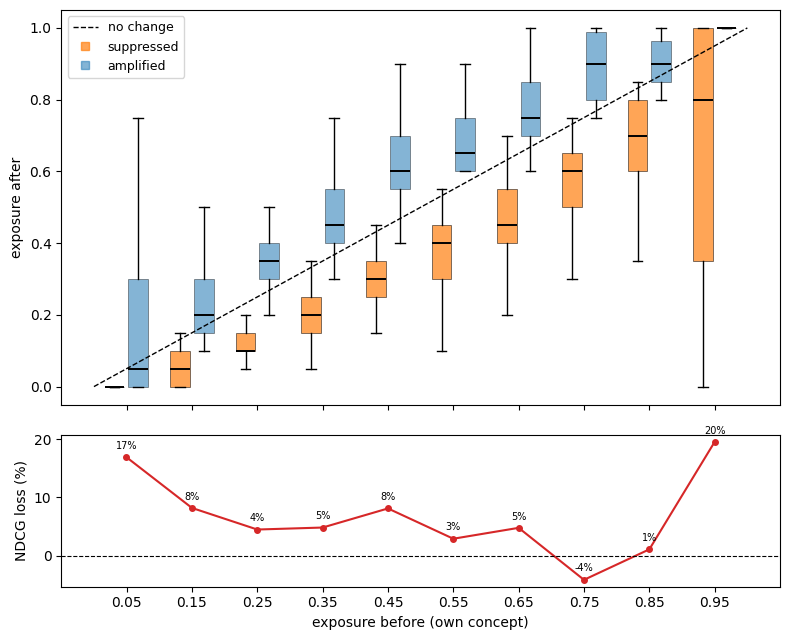

In [153]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

users = df.drop_duplicates(["user_id", "role"]).copy()
bins  = np.arange(0, 1.0001, 0.1)
users["bin_sup"] = pd.cut(users.sup_exposure_before, bins, include_lowest=True)
users["bin_own"] = pd.cut(users.exposure_before,     bins, include_lowest=True)

sup = users[users.role == "suppressed"].groupby("bin_sup", observed=True)
amp = users[users.role == "amplified"].groupby("bin_own", observed=True)

centers_s = np.array([iv.mid for iv in sup.groups.keys()])
centers_a = np.array([iv.mid for iv in amp.groups.keys()])
off = 0.018

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True,
                              gridspec_kw={"height_ratios": [2.6, 1]})

bs = ax.boxplot([g.exposure_after.values for _, g in sup],
                positions=centers_s - off, widths=0.03, showfliers=False,
                patch_artist=True, medianprops=dict(color="black", lw=1.4))
for b in bs["boxes"]:
    b.set(facecolor="tab:orange", alpha=.7, lw=.5)

ba = ax.boxplot([g.exposure_after.values for _, g in amp],
                positions=centers_a + off, widths=0.03, showfliers=False,
                patch_artist=True, medianprops=dict(color="black", lw=1.4))
for b in ba["boxes"]:
    b.set(facecolor="tab:blue", alpha=.55, lw=.5)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="no change")
ax.plot([], [], "s", color="tab:orange", alpha=.7,  label="suppressed")
ax.plot([], [], "s", color="tab:blue",   alpha=.55, label="amplified")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("exposure after")
ax.legend(loc="upper left", fontsize=9)

loss = (1 - sup.ndcg_after.mean() / sup.ndcg_before.mean()).values * 100
ax2.plot(centers_s, loss, "o-", color="tab:red", ms=4)
ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.set_xlim(-0.05, 1.05)
ax2.set_xticks(np.round(centers_s, 2))
ax2.set_xticklabels([f"{c:.2f}" for c in centers_s])
ax2.set_xlabel("exposure before (own concept)")
ax2.set_ylabel("NDCG loss (%)")
for c, v in zip(centers_s, loss):
    ax2.annotate(f"{v:.0f}%", (c, v), textcoords="offset points",
                 xytext=(0, 6), ha="center", fontsize=7)

plt.tight_layout(); plt.show()

In [ ]:
rng  = np.random.default_rng(SEED)   # unused now, harmless
rows = []

AMPLIFY_RANK = 2      # rank of the amplify target (0 = largest c_hat)
assert len(genre_idx) > AMPLIFY_RANK, "not enough concepts"

# adaptive regime: users whose suppressed concept already dominates the top-K
HIGH_EXP_THRESH = 0.9
SUPPRESS_F_HIGH = 0.5
AMPLIFY_F_HIGH  = 20


def ndcg_at_k(topk_idx, pos_items):
    """Leave-one-out NDCG@K: one relevant item per row. -> [B] numpy"""
    hit   = (topk_idx == pos_items.unsqueeze(1))          # [B, K]
    ranks = hit.float().argmax(dim=1)                     # 0-indexed
    found = hit.any(dim=1)
    ndcg  = torch.where(found, 1.0 / torch.log2(ranks.float() + 2),
                        torch.zeros(len(ranks), device=topk_idx.device))
    return ndcg.cpu().numpy()


for batch in test_data:
    interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
    interaction = interaction.to(device)

    # ── baseline ────────────────────────────────────────────────────────
    top_b, c_b, _ = scores_and_chat(cbm, interaction, None, K)
    exp_b_t = genre_exposure(top_b)                         # [B, n_concepts_sel]
    exp_b   = exp_b_t.cpu().numpy()
    B  = len(top_b)
    rr = torch.arange(B, device=device)

    # ── ground-truth item for NDCG ──────────────────────────────────────
    if isinstance(batch, (list, tuple)) and len(batch) >= 4 and batch[3] is not None:
        pos_u, pos_i = batch[2].to(device), batch[3].to(device)
        pos_items = torch.zeros(B, dtype=torch.long, device=device)
        pos_items[pos_u] = pos_i
    else:
        pos_items = interaction[cbm.ITEM_ID]

    cg = c_b[:, genre_idx]                                  # [B, n_sel]

    # rank of each concept by c_hat (0 = highest)
    order = cg.argsort(dim=1, descending=True)
    rank  = torch.empty_like(order)
    rank.scatter_(1, order, torch.arange(cg.size(1), device=device).expand_as(order))
    rank  = rank.cpu().numpy()

    # suppress: rank 0.  amplify: rank AMPLIFY_RANK
    s_col = order[:, 0]
    a_col = order[:, AMPLIFY_RANK]

    s_pick = np.array([genre_idx[c] for c in s_col.cpu().numpy()])
    a_pick = np.array([genre_idx[c] for c in a_col.cpu().numpy()])
    s_pick_t = torch.as_tensor(s_pick, device=device)
    a_pick_t = torch.as_tensor(a_pick, device=device)

    # ── adaptive factors, conditioned on PRE-intervention exposure ──────
    exp_sup = exp_b_t[rr, s_col]                            # [B]
    is_high = exp_sup >= HIGH_EXP_THRESH

    s_factor = torch.where(is_high,
                           torch.full_like(exp_sup, SUPPRESS_F_HIGH),
                           torch.full_like(exp_sup, SUPPRESS_F))
    a_factor = torch.where(is_high,
                           torch.full_like(exp_sup, AMPLIFY_F_HIGH),
                           torch.full_like(exp_sup, AMPLIFY_F))

    factors = torch.ones(B, cbm.n_concepts, device=device)
    factors[rr, s_pick_t] = s_factor
    factors[rr, a_pick_t] = a_factor

    is_high_np = is_high.cpu().numpy()
    exp_sup_np = exp_sup.cpu().numpy()

    # ── steered ─────────────────────────────────────────────────────────
    top_s, _, c_a = scores_and_chat(cbm, interaction, factors, K)
    exp_s = genre_exposure(top_s).cpu().numpy()

    ndcg_b = ndcg_at_k(top_b, pos_items)
    ndcg_s = ndcg_at_k(top_s, pos_items)

    cb, ca = c_b.cpu().numpy(), c_a.cpu().numpy()
    uid = (interaction[cbm.USER_ID].cpu().numpy()
           if cbm.USER_ID in interaction.interaction else np.arange(B))

    # ── one row per (user, measured concept) ────────────────────────────
    for i in range(B):
        for col, j in enumerate(genre_idx):
            role = ("suppressed" if j == s_pick[i] else
                    "amplified"  if j == a_pick[i] else "untargeted")
            rows.append({
                "user_id": int(uid[i]),
                "genre": names[j],
                "role": role,
                "regime": "high" if is_high_np[i] else "normal",
                "sup_exposure_before": float(exp_sup_np[i]),
                "c_hat_rank": int(rank[i, col]),        # 0 = highest c_hat
                "target_suppress": names[s_pick[i]],
                "target_amplify":  names[a_pick[i]],
                "factor": float(factors[i, j]),
                "c_hat_before": float(cb[i, j]),
                "c_hat_after":  float(ca[i, j]),
                "delta_c_hat":  float(ca[i, j] - cb[i, j]),
                "exposure_before": float(exp_b[i, col]),
                "exposure_after":  float(exp_s[i, col]),
                "delta_exposure":  float(exp_s[i, col] - exp_b[i, col]),
                "count_before": int(round(exp_b[i, col] * K)),
                "count_after":  int(round(exp_s[i, col] * K)),
                "ndcg_before": float(ndcg_b[i]),
                "ndcg_after":  float(ndcg_s[i]),
                "delta_ndcg":  float(ndcg_s[i] - ndcg_b[i]),
            })

df = pd.DataFrame(rows)
os.makedirs(os.path.dirname(OUT), exist_ok=True)
df.to_csv(OUT, index=False)

u = df[df.role == "suppressed"].drop_duplicates("user_id")
print(f"{len(df)} rows, {df.user_id.nunique()} users -> {OUT}")
print(f"NDCG@{K}: {u.ndcg_before.mean():.4f} -> {u.ndcg_after.mean():.4f}")
print(u.groupby("regime").agg(
    n=("user_id", "size"),
    mean_exp_before=("exposure_before", "mean"),
    mean_exp_after=("exposure_after", "mean"),
    mean_d_exp=("delta_exposure", "mean"),
    mean_d_c=("delta_c_hat", "mean"),
    ndcg_before=("ndcg_before", "mean"),
    ndcg_after=("ndcg_after", "mean"),
).round(4))

In [152]:
rng  = np.random.default_rng(SEED)   # unused now, harmless
rows = []

AMPLIFY_RANK = 2      # rank of the amplify target (0 = largest c_hat)
assert len(genre_idx) > AMPLIFY_RANK, "not enough concepts"

# (lower_bound, suppress_factor, amplify_factor)
# Matched in order on the suppressed concept's PRE-intervention exposure;
# first band whose lower bound is met wins. Keep sorted descending, and make
# the last band 0.0 so every user is covered.
REGIMES = [
    (0.90, 0.3, 20),    # concept already dominates the top-K
    (0.10, 0.6,  1.7),    # mid-range
    (0, 0.5,  20),    # low baseline exposure
]
assert REGIMES[-1][0] == 0.0, "last band must catch everyone"


def ndcg_at_k(topk_idx, pos_items):
    """Leave-one-out NDCG@K: one relevant item per row. -> [B] numpy"""
    hit   = (topk_idx == pos_items.unsqueeze(1))          # [B, K]
    ranks = hit.float().argmax(dim=1)                     # 0-indexed
    found = hit.any(dim=1)
    ndcg  = torch.where(found, 1.0 / torch.log2(ranks.float() + 2),
                        torch.zeros(len(ranks), device=topk_idx.device))
    return ndcg.cpu().numpy()


for batch in test_data:
    interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
    interaction = interaction.to(device)

    # ── baseline ────────────────────────────────────────────────────────
    top_b, c_b, _ = scores_and_chat(cbm, interaction, None, K)
    exp_b_t = genre_exposure(top_b)                         # [B, n_sel]
    exp_b   = exp_b_t.cpu().numpy()
    B  = len(top_b)
    rr = torch.arange(B, device=device)

    # ── ground-truth item for NDCG ──────────────────────────────────────
    if isinstance(batch, (list, tuple)) and len(batch) >= 4 and batch[3] is not None:
        pos_u, pos_i = batch[2].to(device), batch[3].to(device)
        pos_items = torch.zeros(B, dtype=torch.long, device=device)
        pos_items[pos_u] = pos_i
    else:
        pos_items = interaction[cbm.ITEM_ID]

    cg = c_b[:, genre_idx]                                  # [B, n_sel]

    # rank of each concept by c_hat (0 = highest)
    order = cg.argsort(dim=1, descending=True)
    rank  = torch.empty_like(order)
    rank.scatter_(1, order, torch.arange(cg.size(1), device=device).expand_as(order))
    rank  = rank.cpu().numpy()

    # suppress: rank 0.  amplify: rank AMPLIFY_RANK
    s_col = order[:, 0]
    a_col = order[:, AMPLIFY_RANK]

    s_pick = np.array([genre_idx[c] for c in s_col.cpu().numpy()])
    a_pick = np.array([genre_idx[c] for c in a_col.cpu().numpy()])
    s_pick_t = torch.as_tensor(s_pick, device=device)
    a_pick_t = torch.as_tensor(a_pick, device=device)

    # ── banded factors, conditioned on PRE-intervention exposure ────────
    exp_sup = exp_b_t[rr, s_col]                            # [B]

    s_factor = torch.empty_like(exp_sup)
    a_factor = torch.empty_like(exp_sup)
    band_id  = torch.zeros(B, dtype=torch.long, device=device)
    assigned = torch.zeros(B, dtype=torch.bool, device=device)

    for bi, (lo, sf, af) in enumerate(REGIMES):
        sel = (exp_sup >= lo) & ~assigned
        s_factor[sel] = sf
        a_factor[sel] = af
        band_id[sel]  = bi
        assigned |= sel
    assert assigned.all(), "some users matched no band"

    factors = torch.ones(B, cbm.n_concepts, device=device)
    factors[rr, s_pick_t] = s_factor
    factors[rr, a_pick_t] = a_factor

    band_np    = band_id.cpu().numpy()
    exp_sup_np = exp_sup.cpu().numpy()

    # ── steered ─────────────────────────────────────────────────────────
    top_s, _, c_a = scores_and_chat(cbm, interaction, factors, K)
    exp_s = genre_exposure(top_s).cpu().numpy()

    ndcg_b = ndcg_at_k(top_b, pos_items)
    ndcg_s = ndcg_at_k(top_s, pos_items)

    cb, ca = c_b.cpu().numpy(), c_a.cpu().numpy()
    uid = (interaction[cbm.USER_ID].cpu().numpy()
           if cbm.USER_ID in interaction.interaction else np.arange(B))

    # ── one row per (user, measured concept) ────────────────────────────
    for i in range(B):
        lo_i, sf_i, af_i = REGIMES[band_np[i]]
        for col, j in enumerate(genre_idx):
            role = ("suppressed" if j == s_pick[i] else
                    "amplified"  if j == a_pick[i] else "untargeted")
            rows.append({
                "user_id": int(uid[i]),
                "genre": names[j],
                "role": role,
                "regime": f"[{lo_i:.2f},+)",
                "suppress_factor": float(sf_i),
                "amplify_factor":  float(af_i),
                "sup_exposure_before": float(exp_sup_np[i]),
                "c_hat_rank": int(rank[i, col]),        # 0 = highest c_hat
                "target_suppress": names[s_pick[i]],
                "target_amplify":  names[a_pick[i]],
                "factor": float(factors[i, j]),
                "c_hat_before": float(cb[i, j]),
                "c_hat_after":  float(ca[i, j]),
                "delta_c_hat":  float(ca[i, j] - cb[i, j]),
                "clipped": bool(ca[i, j] >= 1.0 - 1e-6 and factors[i, j] > 1.0),
                "exposure_before": float(exp_b[i, col]),
                "exposure_after":  float(exp_s[i, col]),
                "delta_exposure":  float(exp_s[i, col] - exp_b[i, col]),
                "count_before": int(round(exp_b[i, col] * K)),
                "count_after":  int(round(exp_s[i, col] * K)),
                "ndcg_before": float(ndcg_b[i]),
                "ndcg_after":  float(ndcg_s[i]),
                "delta_ndcg":  float(ndcg_s[i] - ndcg_b[i]),
            })

df = pd.DataFrame(rows)
os.makedirs(os.path.dirname(OUT), exist_ok=True)
df.to_csv(OUT, index=False)

u = df[df.role == "suppressed"].drop_duplicates("user_id")
a = df[df.role == "amplified"].drop_duplicates("user_id")

print(f"{len(df)} rows, {df.user_id.nunique()} users -> {OUT}")
print(f"NDCG@{K}: {u.ndcg_before.mean():.4f} -> {u.ndcg_after.mean():.4f}")

summary = u.groupby("regime").agg(
    n=("user_id", "size"),
    sup_f=("suppress_factor", "first"),
    amp_f=("amplify_factor", "first"),
    exp_before=("exposure_before", "mean"),
    exp_after=("exposure_after", "mean"),
    d_exp_sup=("delta_exposure", "mean"),
    d_c_sup=("delta_c_hat", "mean"),
    ndcg_before=("ndcg_before", "mean"),
    ndcg_after=("ndcg_after", "mean"),
)
summary["d_exp_amp"] = a.groupby("regime").delta_exposure.mean()
summary["amp_clipped"] = a.groupby("regime").clipped.mean()
summary["ndcg_loss_%"] = (1 - summary.ndcg_after / summary.ndcg_before) * 100
summary["exchange"] = summary.d_exp_sup.abs() / (
    (summary.ndcg_before - summary.ndcg_after).abs() + 1e-9)
print(summary.round(4))

18120 rows, 6040 users -> ./dataset/ml-1m/results/local_genre_steering_k20.csv
NDCG@20: 0.2057 -> 0.1820
             n  sup_f  amp_f  exp_before  exp_after  d_exp_sup  d_c_sup  \
regime                                                                    
[0.00,+)   111    0.5   20.0      0.0261     0.0018    -0.0243  -0.2759   
[0.10,+)  3167    0.6    1.7      0.5225     0.3688    -0.1537  -0.2061   
[0.90,+)  2762    0.3   20.0      0.9832     0.6697    -0.3135  -0.5507   

          ndcg_before  ndcg_after  d_exp_amp  amp_clipped  ndcg_loss_%  \
regime                                                                   
[0.00,+)       0.1249      0.1038     0.4468       0.7838      16.9218   
[0.10,+)       0.2061      0.1971     0.0929       0.0000       4.3765   
[0.90,+)       0.2086      0.1678     0.2877       0.3548      19.5329   

          exchange  
regime              
[0.00,+)    1.1507  
[0.10,+)   17.0408  
[0.90,+)    7.6948  


In [73]:
SUPPRESS_GENRE = "Comedy"
AMPLIFY_GENRE  = "Action"

In [15]:
rng  = np.random.default_rng(SEED)
rows = []

rng  = np.random.default_rng(SEED)
rows = []

SUP_J = names.index(SUPPRESS_GENRE)
AMP_J = names.index(AMPLIFY_GENRE)
print(f"suppress {SUPPRESS_GENRE} (idx {SUP_J}) x{SUPPRESS_F} | "
      f"amplify {AMPLIFY_GENRE} (idx {AMP_J}) x{AMPLIFY_F}")

for batch in test_data:
    interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
    interaction = interaction.to(device)

    # baseline
    top_b, c_b, _ = scores_and_chat(cbm, interaction, None, K)
    exp_b = genre_exposure(top_b).cpu().numpy()
    B = len(top_b)

    cg = c_b[:, genre_idx]                                  # [B, n_genres]

    # fixed targets: same genre for every sequence
    s_pick = np.full(B, SUP_J)
    a_pick = np.full(B, AMP_J)

    # rank of each genre by c_hat (0 = highest), for the record
    order = cg.argsort(dim=1, descending=True)
    rank = torch.empty_like(order)
    rank.scatter_(1, order, torch.arange(cg.size(1), device=device).expand_as(order))
    rank = rank.cpu().numpy()

    factors = torch.ones(B, cbm.n_concepts, device=device)
    factors[:, SUP_J] = SUPPRESS_F
    factors[:, AMP_J] = AMPLIFY_F

    # steered
    top_s, _, c_a = scores_and_chat(cbm, interaction, factors, K)
    exp_s = genre_exposure(top_s).cpu().numpy()

    cb, ca = c_b.cpu().numpy(), c_a.cpu().numpy()
    uid = (interaction[cbm.USER_ID].cpu().numpy()
           if cbm.USER_ID in interaction.interaction else np.arange(B))

    for i in range(B):
        for col, j in enumerate(genre_idx):
            role = ("suppressed" if j == s_pick[i] else
                    "amplified"  if j == a_pick[i] else "untargeted")
            rows.append({
                "user_id": int(uid[i]),
                "genre": names[j],
                "role": role,
                "c_hat_rank": int(rank[i, col]),        # 0 = highest c_hat
                "target_suppress": names[s_pick[i]],
                "target_amplify":  names[a_pick[i]],
                "factor": float(factors[i, j]),
                "c_hat_before": float(cb[i, j]),
                "c_hat_after":  float(ca[i, j]),
                "delta_c_hat":  float(ca[i, j] - cb[i, j]),
                "exposure_before": float(exp_b[i, col]),
                "exposure_after":  float(exp_s[i, col]),
                "delta_exposure":  float(exp_s[i, col] - exp_b[i, col]),
                "count_before": int(round(exp_b[i, col] * K)),
                "count_after":  int(round(exp_s[i, col] * K)),
            })

df = pd.DataFrame(rows)
os.makedirs(os.path.dirname(OUT), exist_ok=True)
df.to_csv(OUT, index=False)
print(f"{len(df)} rows, {df.user_id.nunique()} users -> {OUT}")

NameError: name 'SUPPRESS_GENRE' is not defined

In [75]:
data=pd.read_csv("./dataset/ml-1m/results/local_genre_steering_k20.csv")
data[data['user_id']==110]

,user_id,genre,role,c_hat_rank,target_suppress,target_amplify,factor,c_hat_before,c_hat_after,delta_c_hat,exposure_before,exposure_after,delta_exposure,count_before,count_after
106614,110,Action,amplified,8,Comedy,Action,1.2,0.023098,0.027717,0.004620,0.00,0.00,0.00,0,0
106615,110,Adventure,untargeted,17,Comedy,Action,1.0,0.003165,0.003165,0.000000,0.00,0.05,0.05,0,1
106616,110,Animation,untargeted,9,Comedy,Action,1.0,0.022188,0.022188,0.000000,0.00,0.00,0.00,0,0
106617,110,Children's,untargeted,10,Comedy,Action,1.0,0.019347,0.019347,0.000000,0.00,0.00,0.00,0,0
106618,110,Comedy,suppressed,0,Comedy,Action,0.8,0.213766,0.171013,-0.042753,0.15,0.15,0.00,3,3
106619,110,Crime,untargeted,5,Comedy,Action,1.0,0.067773,0.067773,0.000000,0.00,0.00,0.00,0,0
106620,110,Documentary,untargeted,16,Comedy,Action,1.0,0.006670,0.006670,0.000000,0.00,0.00,0.00,0,0
106621,110,Drama,untargeted,3,Comedy,Action,1.0,0.112533,0.112533,0.000000,0.15,0.15,0.00,3,3
106622,110,Fantasy,untargeted,15,Comedy,Action,1.0,0.009130,0.009130,0.000000,0.00,0.00,0.00,0,0
106623,110,Film-Noir,untargeted,14,Comedy,Action,1.0,0.011270,0.011270,0.000000,0.00,0.00,0.00,0,0


In [143]:
rng  = np.random.default_rng(SEED)   # unused now, harmless
rows = []

AMPLIFY_RANK = 2      # rank of the amplify target (0 = largest c_hat)
assert len(genre_idx) > AMPLIFY_RANK, "not enough concepts"

# adaptive regime: users whose suppressed concept already dominates the top-K
HIGH_EXP_THRESH = 0.8
SUPPRESS_F_HIGH = 0.5
AMPLIFY_F_HIGH  = 10


def ndcg_at_k(topk_idx, pos_items):
    """Leave-one-out NDCG@K: one relevant item per row. -> [B] numpy"""
    hit   = (topk_idx == pos_items.unsqueeze(1))          # [B, K]
    ranks = hit.float().argmax(dim=1)                     # 0-indexed
    found = hit.any(dim=1)
    ndcg  = torch.where(found, 1.0 / torch.log2(ranks.float() + 2),
                        torch.zeros(len(ranks), device=topk_idx.device))
    return ndcg.cpu().numpy()


for batch in test_data:
    interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
    interaction = interaction.to(device)

    # ── baseline ────────────────────────────────────────────────────────
    top_b, c_b, _ = scores_and_chat(cbm, interaction, None, K)
    exp_b_t = genre_exposure(top_b)                         # [B, n_concepts_sel]
    exp_b   = exp_b_t.cpu().numpy()
    B  = len(top_b)
    rr = torch.arange(B, device=device)

    # ── ground-truth item for NDCG ──────────────────────────────────────
    if isinstance(batch, (list, tuple)) and len(batch) >= 4 and batch[3] is not None:
        pos_u, pos_i = batch[2].to(device), batch[3].to(device)
        pos_items = torch.zeros(B, dtype=torch.long, device=device)
        pos_items[pos_u] = pos_i
    else:
        pos_items = interaction[cbm.ITEM_ID]

    cg = c_b[:, genre_idx]                                  # [B, n_sel]

    # rank of each concept by c_hat (0 = highest)
    order = cg.argsort(dim=1, descending=True)
    rank  = torch.empty_like(order)
    rank.scatter_(1, order, torch.arange(cg.size(1), device=device).expand_as(order))
    rank  = rank.cpu().numpy()

    # suppress: rank 0.  amplify: rank AMPLIFY_RANK
    s_col = order[:, 0]
    a_col = order[:, AMPLIFY_RANK]

    s_pick = np.array([genre_idx[c] for c in s_col.cpu().numpy()])
    a_pick = np.array([genre_idx[c] for c in a_col.cpu().numpy()])
    s_pick_t = torch.as_tensor(s_pick, device=device)
    a_pick_t = torch.as_tensor(a_pick, device=device)

    # ── adaptive factors, conditioned on PRE-intervention exposure ──────
    exp_sup = exp_b_t[rr, s_col]                            # [B]
    is_high = exp_sup >= HIGH_EXP_THRESH

    s_factor = torch.where(is_high,
                           torch.full_like(exp_sup, SUPPRESS_F_HIGH),
                           torch.full_like(exp_sup, SUPPRESS_F))
    a_factor = torch.where(is_high,
                           torch.full_like(exp_sup, AMPLIFY_F_HIGH),
                           torch.full_like(exp_sup, AMPLIFY_F))

    factors = torch.ones(B, cbm.n_concepts, device=device)
    factors[rr, s_pick_t] = s_factor
    factors[rr, a_pick_t] = a_factor

    is_high_np = is_high.cpu().numpy()
    exp_sup_np = exp_sup.cpu().numpy()

    # ── steered ─────────────────────────────────────────────────────────
    top_s, _, c_a = scores_and_chat(cbm, interaction, factors, K)
    exp_s = genre_exposure(top_s).cpu().numpy()

    ndcg_b = ndcg_at_k(top_b, pos_items)
    ndcg_s = ndcg_at_k(top_s, pos_items)

    cb, ca = c_b.cpu().numpy(), c_a.cpu().numpy()
    uid = (interaction[cbm.USER_ID].cpu().numpy()
           if cbm.USER_ID in interaction.interaction else np.arange(B))

    # ── one row per (user, measured concept) ────────────────────────────
    for i in range(B):
        for col, j in enumerate(genre_idx):
            role = ("suppressed" if j == s_pick[i] else
                    "amplified"  if j == a_pick[i] else "untargeted")
            rows.append({
                "user_id": int(uid[i]),
                "genre": names[j],
                "role": role,
                "regime": "high" if is_high_np[i] else "normal",
                "sup_exposure_before": float(exp_sup_np[i]),
                "c_hat_rank": int(rank[i, col]),        # 0 = highest c_hat
                "target_suppress": names[s_pick[i]],
                "target_amplify":  names[a_pick[i]],
                "factor": float(factors[i, j]),
                "c_hat_before": float(cb[i, j]),
                "c_hat_after":  float(ca[i, j]),
                "delta_c_hat":  float(ca[i, j] - cb[i, j]),
                "exposure_before": float(exp_b[i, col]),
                "exposure_after":  float(exp_s[i, col]),
                "delta_exposure":  float(exp_s[i, col] - exp_b[i, col]),
                "count_before": int(round(exp_b[i, col] * K)),
                "count_after":  int(round(exp_s[i, col] * K)),
                "ndcg_before": float(ndcg_b[i]),
                "ndcg_after":  float(ndcg_s[i]),
                "delta_ndcg":  float(ndcg_s[i] - ndcg_b[i]),
            })

df = pd.DataFrame(rows)
os.makedirs(os.path.dirname(OUT), exist_ok=True)
df.to_csv(OUT, index=False)

u = df[df.role == "suppressed"].drop_duplicates("user_id")
print(f"{len(df)} rows, {df.user_id.nunique()} users -> {OUT}")
print(f"NDCG@{K}: {u.ndcg_before.mean():.4f} -> {u.ndcg_after.mean():.4f}")
print(u.groupby("regime").agg(
    n=("user_id", "size"),
    mean_exp_before=("exposure_before", "mean"),
    mean_exp_after=("exposure_after", "mean"),
    mean_d_exp=("delta_exposure", "mean"),
    mean_d_c=("delta_c_hat", "mean"),
    ndcg_before=("ndcg_before", "mean"),
    ndcg_after=("ndcg_after", "mean"),
).round(4))

18120 rows, 6040 users -> ./dataset/ml-1m/results/local_genre_steering_k20.csv
NDCG@20: 0.2057 -> 0.1916
           n  mean_exp_before  mean_exp_after  mean_d_exp  mean_d_c  \
regime                                                                
high    3256           0.9595          0.7383     -0.2213   -0.3807   
normal  2784           0.4486          0.3612     -0.0874   -0.0996   

        ndcg_before  ndcg_after  
regime                           
high         0.2116      0.1894  
normal       0.1989      0.1941  


In [144]:
df

,user_id,genre,role,regime,sup_exposure_before,c_hat_rank,target_suppress,target_amplify,factor,c_hat_before,c_hat_after,delta_c_hat,exposure_before,exposure_after,delta_exposure,count_before,count_after,ndcg_before,ndcg_after,delta_ndcg
0,6040,classic,amplified,high,0.85,2,modern,classic,10.0,0.177970,1.000000,0.822030,0.00,1.00,1.00,0,20,0.000000,0.000000,0.000000
1,6040,retro,untargeted,high,0.85,1,modern,classic,1.0,0.349080,0.349080,0.000000,0.15,0.00,-0.15,3,0,0.000000,0.000000,0.000000
2,6040,modern,suppressed,high,0.85,0,modern,classic,0.5,0.455669,0.227834,-0.227834,0.85,0.00,-0.85,17,0,0.000000,0.000000,0.000000
3,6039,classic,suppressed,normal,0.70,0,classic,retro,0.8,0.359936,0.287949,-0.071987,0.70,0.55,-0.15,14,11,0.430677,0.386853,-0.043824
4,6039,retro,amplified,normal,0.70,2,classic,retro,1.5,0.317824,0.476737,0.158912,0.15,0.30,0.15,3,6,0.430677,0.386853,-0.043824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18115,2910,retro,untargeted,normal,0.35,1,modern,classic,1.0,0.394472,0.394472,0.000000,0.65,0.75,0.10,13,15,0.000000,0.000000,0.000000
18116,2910,modern,suppressed,normal,0.35,0,modern,classic,0.8,0.543747,0.434997,-0.108749,0.35,0.25,-0.10,7,5,0.000000,0.000000,0.000000
18117,2947,classic,amplified,high,1.00,2,modern,classic,10.0,0.007915,0.079150,0.071235,0.00,0.00,0.00,0,0,0.000000,0.000000,0.000000
18118,2947,retro,untargeted,high,1.00,1,modern,classic,1.0,0.183844,0.183844,0.000000,0.00,0.00,0.00,0,0,0.000000,0.000000,0.000000


In [32]:
for u in all_users:
    data[data['user_id']==u]['role']


In [6]:
display(df.groupby("role").agg(
    n              = ("user_id", "size"),
    mean_delta_c   = ("delta_c_hat", "mean"),
    mean_delta_exp = ("delta_exposure", "mean"),
    pct_moved      = ("delta_exposure", lambda s: (s != 0).mean()),
).round(4))

,n,mean_delta_c,mean_delta_exp,pct_moved
role,,,,
amplified,6040,0.0106,0.0085,0.0791
suppressed,6040,-0.0270,-0.0216,0.1770
untargeted,96640,0.0000,0.0008,0.0301


### Locate the per-genre exposure keys

Depending on how `GenreExposure` is registered, per-genre values arrive either as
`genreexposure@10::Rock` (dict-valued) or as separate top-level keys. This resolves
either shape into `genre -> key`.

In [11]:
def find_genre_keys(res, genre_names):
    mapping = {}
    for g in genre_names:
        cands = [k for k in res
                 if k.lower().endswith(("::" + g).lower())
                 or (g.lower() in k.lower() and "genre" in k.lower())]
        if cands:
            mapping[g] = sorted(cands, key=len)[0]
    return mapping

GKEY = find_genre_keys(res_base, genre_names)
missing = [g for g in genre_names if g not in GKEY]
print(f"resolved {len(GKEY)}/{len(genre_names)} genre exposure keys")
if missing:
    print("MISSING:", missing)
    print("available:", [k for k in res_base if "genre" in k.lower()])
assert GKEY, "GenreExposure did not produce per-genre keys — check the metric registration"

print("baseline exposure:")
for g in genre_names:
    if g in GKEY:
        print(f"  {g:<16} {res_base[GKEY[g]]:.4f}")

resolved 18/18 genre exposure keys
baseline exposure:
  Action           0.0293
  Adventure        0.0058
  Animation        0.0410
  Children's       0.0387
  Comedy           0.1770
  Crime            0.0656
  Documentary      0.0081
  Drama            0.0988
  Fantasy          0.0121
  Film-Noir        0.0229
  Horror           0.0719
  Musical          0.0234
  Mystery          0.0263
  Romance          0.1056
  Sci-Fi           0.1188
  Thriller         0.0837
  War              0.0453
  Western          0.0255


## 5. Sweep

One genre at a time. `factor = 1.0` is a no-op and acts as an internal control: its rows
should show `delta_exposure ≈ 0` everywhere. If they don't, something is nondeterministic
and nothing else in the table is trustworthy.

In [22]:
grid

[('Action', 0.0),
 ('Action', 0.25),
 ('Action', 0.5),
 ('Action', 0.75),
 ('Action', 1.0),
 ('Action', 1.5),
 ('Action', 2.0),
 ('Action', 3.0),
 ('Action', 5.0),
 ('Adventure', 0.0),
 ('Adventure', 0.25),
 ('Adventure', 0.5),
 ('Adventure', 0.75),
 ('Adventure', 1.0),
 ('Adventure', 1.5),
 ('Adventure', 2.0),
 ('Adventure', 3.0),
 ('Adventure', 5.0),
 ('Animation', 0.0),
 ('Animation', 0.25),
 ('Animation', 0.5),
 ('Animation', 0.75),
 ('Animation', 1.0),
 ('Animation', 1.5),
 ('Animation', 2.0),
 ('Animation', 3.0),
 ('Animation', 5.0),
 ("Children's", 0.0),
 ("Children's", 0.25),
 ("Children's", 0.5),
 ("Children's", 0.75),
 ("Children's", 1.0),
 ("Children's", 1.5),
 ("Children's", 2.0),
 ("Children's", 3.0),
 ("Children's", 5.0),
 ('Comedy', 0.0),
 ('Comedy', 0.25),
 ('Comedy', 0.5),
 ('Comedy', 0.75),
 ('Comedy', 1.0),
 ('Comedy', 1.5),
 ('Comedy', 2.0),
 ('Comedy', 3.0),
 ('Comedy', 5.0),
 ('Crime', 0.0),
 ('Crime', 0.25),
 ('Crime', 0.5),
 ('Crime', 0.75),
 ('Crime', 1.0),
 ('

In [12]:
rows = []
grid = list(itertools.product(targets, FACTORS))

for target, factor in tqdm(grid):
    j = genre_pos[target]


    cbm._n_clipped = cbm._n_seen = 0

    res = flatten(evaluate_with_recbole(cbm, config, train_data, test_data,
                                        interventions={j: float(factor)}))
    clip_rate = cbm._n_clipped / max(cbm._n_seen, 1)

    for g in genre_names:
        if g not in GKEY:
            continue
        before, after = res_base[GKEY[g]], res[GKEY[g]]
        rows.append({
            "steered_genre": target,
            "steered_idx": j,
            "factor": float(factor),
            "direction": ("suppress" if factor < 1 else
                          "amplify"  if factor > 1 else "none"),
            "measured_genre": g,
            "role": "target" if g == target else "untargeted",
            "exposure_before": before,
            "exposure_after": after,
            "delta_exposure": after - before,
            "rel_change": (after - before) / before if before > 0 else np.nan,
            # global quality/diversity for this run, repeated per row
            f"ndcg@{TOPK}":        res.get(f"ndcg@{TOPK}", np.nan),
            f"recall@{TOPK}":      res.get(f"recall@{TOPK}", np.nan),
            f"itemcoverage@{TOPK}": res.get(f"itemcoverage@{TOPK}", np.nan),
            f"giniindex@{TOPK}":   res.get(f"giniindex@{TOPK}", np.nan),
            f"averagepopularity@{TOPK}": res.get(f"averagepopularity@{TOPK}", np.nan),
            "clip_rate": clip_rate,
            "k": TOPK,
        })

    pd.DataFrame(rows).to_csv(OUT, index=False)     # checkpoint each iteration

clear_steering(cbm)
df = pd.DataFrame(rows)
os.makedirs(os.path.dirname(OUT), exist_ok=True)
df.to_csv(OUT, index=False)
print(f"{len(df)} rows -> {OUT}")

  0%|          | 0/162 [00:00<?, ?it/s]

2916 rows -> ./dataset/ml-1m/results/genre_steering_ml-1m_k10.csv


In [16]:
all_datas=pd.read_csv("./dataset/ml-1m/results/genre_steering_ml-1m_k10.csv")

In [17]:
all_datas

,steered_genre,steered_idx,factor,direction,measured_genre,role,exposure_before,exposure_after,delta_exposure,rel_change,ndcg@10,recall@10,itemcoverage@10,giniindex@10,averagepopularity@10,clip_rate,k
0,Action,0,0.0,suppress,Action,target,0.0293,0.0132,-0.0161,-0.549488,0.1380,0.2578,0.6898,0.7436,834.9449,0.000000,10
1,Action,0,0.0,suppress,Adventure,untargeted,0.0058,0.0053,-0.0005,-0.086207,0.1380,0.2578,0.6898,0.7436,834.9449,0.000000,10
2,Action,0,0.0,suppress,Animation,untargeted,0.0410,0.0416,0.0006,0.014634,0.1380,0.2578,0.6898,0.7436,834.9449,0.000000,10
3,Action,0,0.0,suppress,Children's,untargeted,0.0387,0.0415,0.0028,0.072351,0.1380,0.2578,0.6898,0.7436,834.9449,0.000000,10
4,Action,0,0.0,suppress,Comedy,untargeted,0.1770,0.1776,0.0006,0.003390,0.1380,0.2578,0.6898,0.7436,834.9449,0.000000,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2911,Western,17,5.0,amplify,Romance,untargeted,0.1056,0.1014,-0.0042,-0.039773,0.1376,0.2593,0.6918,0.7450,834.5760,0.000579,10
2912,Western,17,5.0,amplify,Sci-Fi,untargeted,0.1188,0.1144,-0.0044,-0.037037,0.1376,0.2593,0.6918,0.7450,834.5760,0.000579,10
2913,Western,17,5.0,amplify,Thriller,untargeted,0.0837,0.0833,-0.0004,-0.004779,0.1376,0.2593,0.6918,0.7450,834.5760,0.000579,10
2914,Western,17,5.0,amplify,War,untargeted,0.0453,0.0506,0.0053,0.116998,0.1376,0.2593,0.6918,0.7450,834.5760,0.000579,10


## 6. Read it

### Control check first

In [ ]:
ctrl = df[df.factor == 1.0]
print(f"factor=1.0 max |delta_exposure| = {ctrl.delta_exposure.abs().max():.2e}"
      "   (should be ~0)")

### Target effect: does scaling a genre move its own exposure?

In [ ]:
tgt = (df[df.role == "target"]
       .pivot_table(index="steered_genre", columns="factor",
                    values="delta_exposure"))
display(tgt.round(4))

### Accuracy cost

Per run, so it repeats across measured-genre rows — deduplicate on (genre, factor).

In [ ]:
cost = (df.drop_duplicates(["steered_genre", "factor"])
        .pivot_table(index="steered_genre", columns="factor",
                     values=f"ndcg@{TOPK}"))
base_ndcg = res_base[f"ndcg@{TOPK}"]
print(f"baseline NDCG@{TOPK} = {base_ndcg:.4f}")
display((cost / base_ndcg).round(3))       # 1.000 = no loss

### Spillover matrix

Rows = steered genre, columns = measured genre, values = mean `delta_exposure` on the
untargeted genres. Off-diagonal mass is concept entanglement.

Pick one factor rather than averaging across them — the effect is not linear in the
factor, so a mean over 0.0 through 5.0 is not interpretable.

In [ ]:
FACTOR_FOR_SPILL = 2.0

spill = (df[(df.role == "untargeted") & (df.factor == FACTOR_FOR_SPILL)]
         .pivot_table(index="steered_genre", columns="measured_genre",
                      values="delta_exposure"))
display(spill.round(4))

flat = spill.stack().rename("delta_exposure").reset_index()
display(flat.reindex(flat.delta_exposure.abs()
                     .sort_values(ascending=False).index).head(15))

### Specificity

Target effect relative to total movement. 1.0 means the intervention moved only its own
genre; near 0 means it mostly moved everything else.

In [ ]:
spec = []
for (g, f), sub in df.groupby(["steered_genre", "factor"]):
    t = sub[sub.role == "target"].delta_exposure.abs().sum()
    o = sub[sub.role == "untargeted"].delta_exposure.abs().sum()
    spec.append({"steered_genre": g, "factor": f,
                 "target_abs": t, "collateral_abs": o,
                 "specificity": t / (t + o) if (t + o) > 0 else np.nan})

spec = pd.DataFrame(spec)
display(spec.pivot_table(index="steered_genre", columns="factor",
                         values="specificity").round(3))

### Cross-check against the closed form

Your reconstructor is a single `nn.Linear` with no activation, so
`h_hat = W_c·c_hat + W_z·z + b` and a change in concept *j* shifts every item's score by
`Δc_j · (prop_item_e @ W_c[:, j])`. That direction is identical for every user, so
predicted spillover between genres *j* and *k* is just the cosine between their
directions — no evaluation needed.

Where the measured spillover matrix tracks this one, you have real concept entanglement.
Where it doesn't, you're seeing clipping or out-of-range `c_hat`.

In [ ]:
from concept_geometry import entanglement_matrix, leverage

E = entanglement_matrix(cbm)[:n_genres, :n_genres]
lev = leverage(cbm)[:n_genres]

pred = pd.DataFrame(E, index=genre_names, columns=genre_names)
display(pd.Series(lev, index=genre_names)
        .sort_values(ascending=False).round(3).to_frame("leverage ||v_j||"))

common = [g for g in genre_names if g in spill.index and g in spill.columns]
m = spill.loc[common, common].values.flatten()
p = pred.loc[common, common].values.flatten()
ok = ~np.isnan(m)
print(f"corr(measured spillover, predicted cos) = {np.corrcoef(m[ok], p[ok])[0,1]:.3f}")